<a href="https://colab.research.google.com/github/krish-Algometrix/Applied_Artificial_Intelligence/blob/main/Corrosion_Detection_CNNtransferlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The aim of this project is to use industrial images of manufactirung piping lines to identify corrosion and classify them as corroded and non corroded pipelines.

Project approach
1. Image data set imported from Roboflow library through their API.
2. The images of corrosion are synthetic but curated from original industrial images.
3. Computational platform _ Tensiorflow and OpnCV for image data processing and deep learning algorithms and optimization with Tensorflow.
4. We will use performance metric from both tensorflow library or sklearn library for analysis of classification results.

In [ ]:
import keras
import tensorflow as tf
from keras.applications import VGG16
from keras.utils.vis_utils import plot_model
import os, shutil
from keras import models
from keras import layers
from keras import optimizers
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras import models
from keras.preprocessing import image
import numpy as np
import sklearn.metrics
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import itertools
import seaborn
import tensorboard as tb
import datetime as date

In [ ]:
pip install pillow

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ZI3VLiB9ApvopfJzctf1")
project = rf.workspace("synthetic-corrosion").project("synthetic-corrosion-dataset")
cor_data = project.version(3).download("folder")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.6 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=039bb77c203c62ba7e35a55f561e2afe9b76f8aade3d87c2a6df7c1600f03f5b
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.1.0
    Uninstalling pyparsing-3.1.0:
      Su

loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to Synthetic-Corrosion-Dataset-3 in folder:: 100%|██████████| 303/303 [00:00<00:00, 1170.63it/s]


In [ ]:
type(cor_data)

roboflow.core.dataset.Dataset

In [ ]:
pip install tensorflow

In [ ]:
pip install keras

In [ ]:
import tensorflow as tf
import keras

In [ ]:
# checking for version
tf.__version__
keras.__version__

'2.12.0'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import cv2
import PIL

In [ ]:
import cv2
cv2.__version__

'4.7.0'

In [ ]:
from google.colab.patches import cv2_imshow


In [ ]:
categories = ['corrosion','no-corrosion']

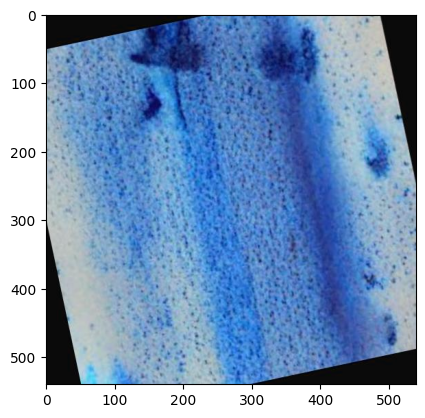

In [ ]:
image_1 = cv2.imread('/content/Synthetic-Corrosion-Dataset-3/train/Corrosion/craiyon_082033_rust_on_a_metal_surface_png_jpg.rf.05b8b2d42e101b838df859f711a320fa.jpg')
plt.imshow(image_1)

In [ ]:
# using matplotlib to read and display the rust surface as matplotlib uses RGB channels
image_2 = img.imread('/content/Synthetic-Corrosion-Dataset-3/train/Corrosion/craiyon_082033_rust_on_a_metal_surface_png_jpg.rf.05b8b2d42e101b838df859f711a320fa.jpg')

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

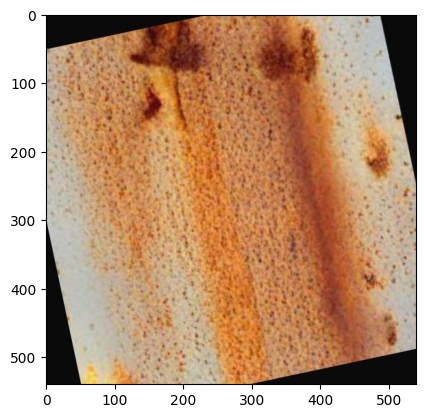

In [ ]:
plt.imshow(image_2)

In [ ]:
# defining a function to load and read images from the folder
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
        if len(images)>3:
            break
    fig=plt.figure(figsize=(10,12))
    xrange=range(1,5)

    for img,x in zip(images,xrange):
        ax=fig.add_subplot(2,2,x)
        ax.imshow(img)
        ax.set_title(img.shape)

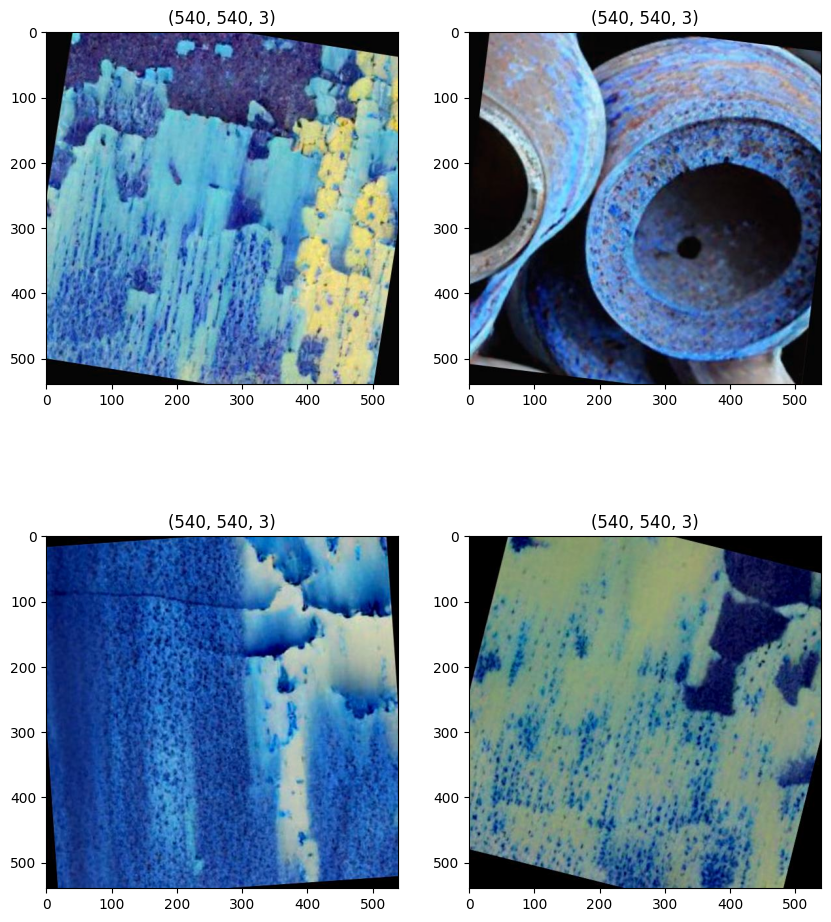

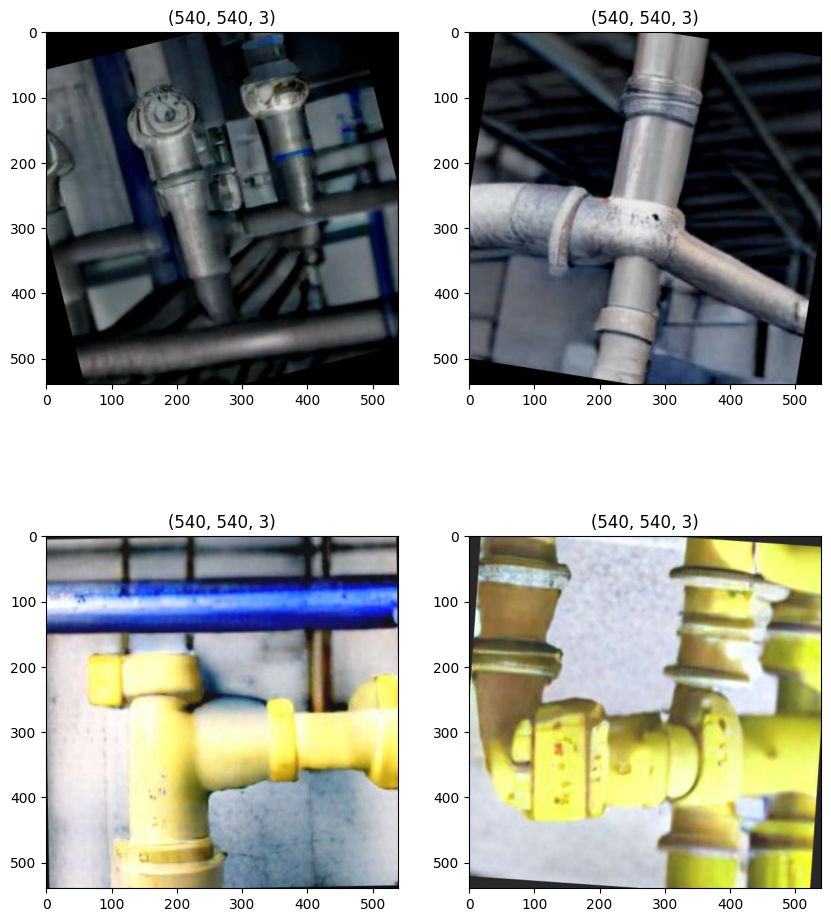

In [ ]:
rust_images = load_images_from_folder(r"/content/Synthetic-Corrosion-Dataset-3/train/Corrosion")
norust_images =load_images_from_folder(r'/content/Synthetic-Corrosion-Dataset-3/train/no-corrosion')

In [ ]:
base_dir = '/content/Synthetic-Corrosion-Dataset-3'
base_dir_rusttrain = '/content/Synthetic-Corrosion-Dataset-3/train/Corrosion'
base_dir_norusttrain ='/content/Synthetic-Corrosion-Dataset-3/train/no-corrosion'
base_dir_rusttest = '/content/Synthetic-Corrosion-Dataset-3/test/Corrosion'
base_dir_norusttest = '/content/Synthetic-Corrosion-Dataset-3/test/no-corrosion'
base_dir_rustvalid = '/content/Synthetic-Corrosion-Dataset-3/valid/Corrosion'
base_dir_norustvalid = '/content/Synthetic-Corrosion-Dataset-3/valid/no-corrosion'

In [ ]:
test_path = '/content/Synthetic-Corrosion-Dataset-3/test/'
train_path = '/content/Synthetic-Corrosion-Dataset-3/train/'
valid_path = '/content/Synthetic-Corrosion-Dataset-3/valid/'

In [ ]:
corrosion = "/Corrosion"
no_corrosion = "/no-corrosion"

We import the glob module in collab.  The glob module, which is short for global, is a function that's used to search for files that match a specific file pattern or name. It can be used to search CSV files and for text in files.

In [ ]:
import glob

In [ ]:
train_corrosion = [cv2.imread(rust) for rust in glob.glob(train_path+corrosion+"/*.jpg")]
test_corrosion = [cv2.imread(rust) for rust in glob.glob(test_path+corrosion+"/*.jpg")]
valid_corrosion = [cv2.imread(rust) for rust in glob.glob(valid_path+corrosion+"/*.jpg")]

In [ ]:
type(train_corrosion)

list

In [ ]:
# check
valid_corrosion[1]

array([[[ 36,  23,  15],
        [ 18,  19,  15],
        [ 19,  45,  52],
        ...,
        [145, 168, 140],
        [144, 163, 136],
        [140, 159, 132]],

       [[ 29,  19,  12],
        [ 43,  46,  44],
        [ 57,  86,  93],
        ...,
        [147, 170, 142],
        [144, 166, 138],
        [143, 162, 135]],

       [[ 19,  14,  11],
        [ 69,  79,  79],
        [ 93, 129, 137],
        ...,
        [151, 173, 148],
        [148, 169, 144],
        [146, 167, 142]],

       ...,

       [[ 50,  25,   0],
        [118,  97,  52],
        [206, 190, 121],
        ...,
        [  3,  76, 167],
        [  4,  75, 166],
        [  5,  75, 166]],

       [[ 44,  20,   0],
        [ 71,  51,  10],
        [148, 132,  65],
        ...,
        [  9,  88, 175],
        [  8,  84, 174],
        [  7,  83, 173]],

       [[ 55,  32,   6],
        [ 42,  21,   0],
        [ 92,  76,  10],
        ...,
        [ 14,  94, 181],
        [ 11,  89, 179],
        [  9,  87, 177]]

In [ ]:
train_nocorrosion = [cv2.imread(norust) for norust in glob.glob(train_path+no_corrosion+"/*.jpg")]
test_nocorrosion = [cv2.imread(norust) for norust in glob.glob(test_path+no_corrosion+"/*.jpg")]
valid_nocorrosion = [cv2.imread(norust) for norust in glob.glob(valid_path+no_corrosion+"/*.jpg")]

In [ ]:
train_corrosion = tf.convert_to_tensor(train_corrosion,dtype=tf.float32)
train_nocorrosion = tf.convert_to_tensor(train_nocorrosion, dtype = tf.float32)

In [ ]:
test_corrosion = tf.convert_to_tensor(test_corrosion,dtype=tf.float32)
test_nocorrosion = tf.convert_to_tensor(test_corrosion,dtype=tf.float32)
valid_corrosion = tf.convert_to_tensor(valid_corrosion,dtype=tf.float32)
valid_nocorrosion = tf.convert_to_tensor(valid_nocorrosion,dtype=tf.float32)

In [ ]:
# we have now converted the images into tensors of floating 32 bit and then check the shape of the same.
print(train_corrosion.shape)
print(train_nocorrosion.shape)
print(valid_corrosion.shape)
print(valid_nocorrosion.shape)
print(test_corrosion.shape)
print(test_nocorrosion.shape)

(225, 540, 540, 3)
(45, 540, 540, 3)
(11, 540, 540, 3)
(3, 540, 540, 3)
(7, 540, 540, 3)
(7, 540, 540, 3)


In [ ]:
# as we can see we can rescale the image h and w

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_corrosion = tf.image.resize(
    train_corrosion,
    [150,150],
    method = 'nearest',
    preserve_aspect_ratio= True,
    antialias=True,
    name=None
)

In [ ]:
train_nocorrosion = tf.image.resize(
    train_nocorrosion,
    [150,150],
    method = 'nearest',
    preserve_aspect_ratio= True,
    antialias=True,
    name=None
)


In [ ]:
test_corrosion = tf.image.resize(
    test_corrosion,
    [150,150],
    method = 'nearest',
    preserve_aspect_ratio= True,
    antialias=True,
    name=None
)

In [ ]:
test_nocorrosion = tf.image.resize(
    test_nocorrosion,
    [150,150],
    method = 'nearest',
    preserve_aspect_ratio= True,
    antialias=True,
    name=None
)

In [ ]:
valid_corrosion = tf.image.resize(
    valid_corrosion,
    [150,150],
    method = 'nearest',
    preserve_aspect_ratio= True,
    antialias=True,
    name=None
)

In [ ]:
valid_nocorrosion = tf.image.resize(
    valid_nocorrosion,
    [150,150],
    method = 'nearest',
    preserve_aspect_ratio= True,
    antialias=True,
    name=None
)

In [ ]:
# checking resized images
print(train_corrosion.shape)
print(train_nocorrosion.shape)
print(test_corrosion.shape)
print(test_nocorrosion.shape)
print(valid_corrosion.shape)
print(valid_nocorrosion.shape)


(225, 150, 150, 3)
(45, 150, 150, 3)
(7, 150, 150, 3)
(7, 150, 150, 3)
(11, 150, 150, 3)
(3, 150, 150, 3)


Now we set the training data, validation data and test data for model fit and classification

In [ ]:
class_names = Train_cor_noncor.class_names
print("Number of Class names :", len(class_names))
print(class_names)

Number of Class names : 2
['Corrosion', 'no-corrosion']


In [ ]:
class_names2 = valid_cor_noncor.class_names
print("Number of Class names :", len(class_names))
print(class_names)

Number of Class names : 2
['Corrosion', 'no-corrosion']


In [ ]:
for image_batch, labels_batch in Train_cor_noncor:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 150, 150, 3)
(32,)


In [ ]:
for image_batch, labels_batch in valid_cor_noncor:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 150, 150, 3)
(32,)


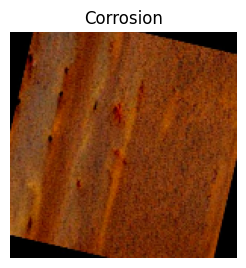

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(len(class_names)):
    filtered_ds = Train_cor_noncor.filter(lambda x, l: tf.math.equal(l[0], i))
    for image, label in filtered_ds.take(1):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(image[0].numpy().astype('uint8'))
        plt.title(class_names[label.numpy()[0]])
        plt.axis('off')

In [ ]:
Train_cor_noncor = image_dataset_from_directory('/content/Synthetic-Corrosion-Dataset-3/train',labels='inferred',batch_size =32,image_size =(150,150),validation_split=0.20,subset ='training',seed =123)


Found 270 files belonging to 2 classes.
Using 216 files for training.


In [ ]:
valid_cor_noncor = image_dataset_from_directory('/content/Synthetic-Corrosion-Dataset-3/train',labels='inferred',validation_split=0.2,batch_size=32,image_size=(150, 150),subset='validation',seed=123)

Found 270 files belonging to 2 classes.
Using 54 files for validation.


In [ ]:
# we choose a pre-trainned model VGG16 to train on our sample corrosion dataset
conv_base = VGG16(weights='imagenet',include_top=False,input_shape=(150,150, 3))

58889256/58889256 [==============================] - 0s 0us/step


In [ ]:
# understanding the model architecture of VGG16
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

Now on top of the VGG16 layer we add our additional layers using the model.add layer functions

In [ ]:
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))     # configuring the final output layer


In [ ]:
model.summary()     # understanding the model summary after configuration as above.

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 16,812,353
Non-trainable params: 0
_________________________________________________________________


freeze the convolution base layers such that we can reduce the number of parameters and the model will train on only the fully connected layers

In [ ]:
conv_base.trainable = False

In [ ]:
pip install tensorboard

In [ ]:
tf.timestamp

<function tensorflow.python.ops.gen_logging_ops.timestamp(name=None)>

In [ ]:
tensorboard = keras.callbacks.TensorBoard(log_dir='logs/{}'.format(tf.timestamp()))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(Train_cor_noncor,epochs =10,batch_size =32,validation_data =valid_cor_noncor,verbose =2,callbacks =[tensorboard])

Epoch 1/10
7/7 - 102s - loss: 1.3167e-07 - accuracy: 1.0000 - val_loss: 0.0865 - val_accuracy: 0.9815 - 102s/epoch - 15s/step
Epoch 2/10
7/7 - 71s - loss: 1.2706e-07 - accuracy: 1.0000 - val_loss: 0.0864 - val_accuracy: 0.9815 - 71s/epoch - 10s/step
Epoch 3/10
7/7 - 80s - loss: 1.2372e-07 - accuracy: 1.0000 - val_loss: 0.0864 - val_accuracy: 0.9815 - 80s/epoch - 11s/step
Epoch 4/10
7/7 - 77s - loss: 1.1991e-07 - accuracy: 1.0000 - val_loss: 0.0864 - val_accuracy: 0.9815 - 77s/epoch - 11s/step
Epoch 5/10
7/7 - 84s - loss: 1.1482e-07 - accuracy: 1.0000 - val_loss: 0.0864 - val_accuracy: 0.9815 - 84s/epoch - 12s/step
Epoch 6/10
7/7 - 80s - loss: 1.1253e-07 - accuracy: 1.0000 - val_loss: 0.0864 - val_accuracy: 0.9815 - 80s/epoch - 11s/step
Epoch 7/10
7/7 - 76s - loss: 1.0884e-07 - accuracy: 1.0000 - val_loss: 0.0864 - val_accuracy: 0.9815 - 76s/epoch - 11s/step
Epoch 8/10
7/7 - 79s - loss: 1.0586e-07 - accuracy: 1.0000 - val_loss: 0.0863 - val_accuracy: 0.9815 - 79s/epoch - 11s/step
Epoch 

In [ ]:
accuracy = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(accuracy)+1)

<Figure size 640x480 with 0 Axes>

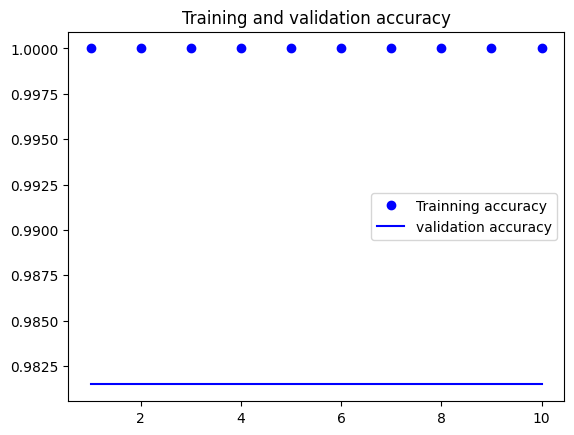

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(epochs,accuracy,'bo',label ='Trainning accuracy')
plt.plot(epochs,val_acc,'b',label ='validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

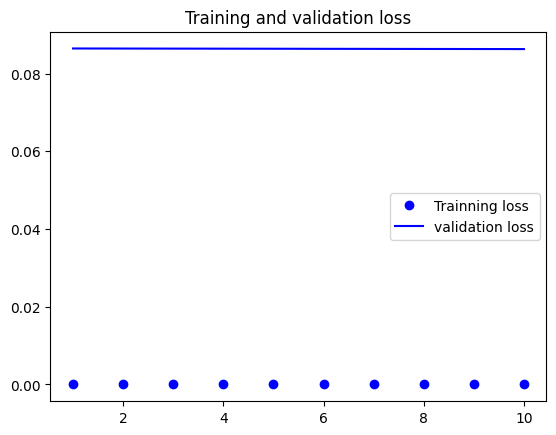

In [ ]:
plt.plot(epochs,loss,'bo',label ='Trainning loss')
plt.plot(epochs,val_loss,'b',label ='validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()


In [ ]:
Test_cornocor = image_dataset_from_directory('/content/Synthetic-Corrosion-Dataset-3/test',labels='inferred',  batch_size=32, image_size=(150, 150),shuffle =False)

Found 8 files belonging to 2 classes.


In [ ]:
test_loss, test_acc = model.evaluate(Test_cornocor)
print('test acc:', test_acc)

1/1 [==============================] - 2s 2s/step - loss: 0.6617 - accuracy: 0.8750
test acc: 0.875


We note that Test accuracy after running the model on Test data os 87.50 percent .

With this we conclude the implementation of VGG16 for classification of corrosion and non corrosion industrial data using computer vision problem solving